In [1]:
# @title Configuração de Ambiente
!pip -q install deap numpy matplotlib

import os
import warnings
warnings.filterwarnings('ignore')
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

print("✅ Ambiente configurado (DEAP, NumPy, Matplotlib) — CPU forçada, logs silenciados")
# Saída de Célula Esperada: ✅ Ambiente configurado (DEAP, NumPy, Matplotlib) — CPU forçada, logs silenciados


[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: pip install --upgrade pip
✅ Ambiente configurado (DEAP, NumPy, Matplotlib) — CPU forçada, logs silenciados
✅ Ambiente configurado (DEAP, NumPy, Matplotlib) — CPU forçada, logs silenciados


# Workshop Prático — Aula 7: SBST com DEAP

Objetivo: implementar um gerador de testes evolutivo (DEAP) que maximiza a cobertura de ramos de uma função complexa, com instrumentação baseada em `sys.settrace`.

In [2]:
# @title Instrumentador de cobertura e função-alvo
from typing import Callable, Dict, List, Set, Tuple
import sys
import random
import numpy as np

_ACTIVE_COVERAGE_SET: Set[str] = set()

def record_branch(branch_id: str) -> None:
    """Registra a ativação de um ramo identificado por uma string.

    Parameters
    ----------
    branch_id : str
        Identificador único do ramo (ex.: 'tipo_invalido', 'equilatero', etc.).
    """
    if isinstance(_ACTIVE_COVERAGE_SET, set):
        _ACTIVE_COVERAGE_SET.add(branch_id)

class CoverageInstrumenter:
    """Instrumenta a execução de uma função-alvo para coletar ramos cobertos.

    Usa sys.settrace para isolar a execução da função-alvo. A coleta de cobertura
    é feita por marcadores explícitos via `record_branch(...)` inseridos na função.

    Essa abordagem é não invasiva, pedagógica e suficiente para fins de SBST.
    """
    def __init__(self, target_func: Callable[..., object]) -> None:
        """Cria um instrumentador para uma função.

        Parameters
        ----------
        target_func : Callable[..., object]
            Função Python a instrumentar.
        """
        self.target_func = target_func
        self.captured: Set[str] = set()

    def _tracer(self, frame, event, arg):
        # Mantemos o tracer simples; ele apenas garante que a execução está
        # sob rastreamento enquanto os marcadores preenchem o conjunto ativo.
        return self._tracer

    def run(self, *args, **kwargs) -> Tuple[object, Set[str]]:
        """Executa a função-alvo capturando os ramos ativados.

        Returns
        -------
        Tuple[object, Set[str]]
            Resultado da função e o conjunto de ramos cobertos nesta execução.
        """
        global _ACTIVE_COVERAGE_SET
        previous = _ACTIVE_COVERAGE_SET
        _ACTIVE_COVERAGE_SET = set()
        sys.settrace(self._tracer)
        try:
            result = self.target_func(*args, **kwargs)
        finally:
            sys.settrace(None)
            self.captured = set(_ACTIVE_COVERAGE_SET)
            _ACTIVE_COVERAGE_SET = previous
        return result, set(self.captured)

# Documento dos ramos esperados (meta de cobertura)
EXPECTED_BRANCHES: Set[str] = set([
    'tipo_invalido', 'nao_positivo', 'zero_invalido',
    'borda_inequidade', 'nao_triangulo', 'triangulo_valido',
    'equilatero', 'isosceles', 'escaleno',
    'retangulo', 'obtusangulo', 'acutangulo',
])

def classificador_triangulo_complexo(a: int, b: int, c: int) -> str:
    """Classifica um triângulo com validações, tipos e ângulos.

    Parameters
    ----------
    a, b, c : int
        Lados do triângulo.

    Returns
    -------
    str
        Categoria combinada, p.ex. 'escaleno-ret', 'equilatero-acu'
        ou 'invalid'/'nao_triangulo'.
    """
    # Tipos válidos
    if not all(isinstance(x, int) for x in (a, b, c)):
        record_branch('tipo_invalido')
        return 'invalid'

    # Domínio
    if a == 0 or b == 0 or c == 0:
        record_branch('zero_invalido')
        return 'invalid'
    if a < 0 or b < 0 or c < 0:
        record_branch('nao_positivo')
        return 'invalid'

    # Ordena para facilitar verificações
    x, y, z = sorted([a, b, c])

    # Desigualdade triangular
    if x + y == z:
        record_branch('borda_inequidade')
        return 'nao_triangulo'
    if x + y < z:
        record_branch('nao_triangulo')
        return 'nao_triangulo'
    record_branch('triangulo_valido')

    # Por lados
    if a == b == c:
        tipo = 'equilatero'
        record_branch('equilatero')
    elif a == b or b == c or a == c:
        tipo = 'isosceles'
        record_branch('isosceles')
    else:
        tipo = 'escaleno'
        record_branch('escaleno')

    # Por ângulo (Pitágoras generalizado)
    x2, y2, z2 = x*x, y*y, z*z
    if z2 == x2 + y2:
        ang = 'ret'
        record_branch('retangulo')
    elif z2 > x2 + y2:
        ang = 'obt'
        record_branch('obtusangulo')
    else:
        ang = 'acu'
        record_branch('acutangulo')

    return f'{tipo}-{ang}'

# Smoke test
ins = CoverageInstrumenter(classificador_triangulo_complexo)
_, covered = ins.run(3, 4, 5)
print(f"✅ Instrumentação ativa. Ramos cobertos por (3,4,5): {sorted(list(covered))}")
# Saída Esperada: inclui 'triangulo_valido', 'escaleno', 'retangulo'

✅ Instrumentação ativa. Ramos cobertos por (3,4,5): ['escaleno', 'retangulo', 'triangulo_valido']


## Parte 2 — Baseline com testes aleatórios
Geramos amostras aleatórias e medimos a cobertura sem otimização para evidenciar o platô de descoberta de ramos raros.

In [3]:
# @title Baseline de cobertura via amostragem aleatória
def random_case(low: int = -5, high: int = 50) -> Tuple[int, int, int]:
    """Gera um trio aleatório (a, b, c) no intervalo dado.

    Returns
    -------
    Tuple[int, int, int]
        Valores inteiros de lados.
    """
    return (
        random.randint(low, high),
        random.randint(low, high),
        random.randint(low, high),
    )

def random_baseline(n_samples: int = 1500) -> Set[str]:
    """Executa n amostras aleatórias e retorna ramos cobertos.

    Parameters
    ----------
    n_samples : int
        Número de amostras aleatórias.

    Returns
    -------
    Set[str]
        Conjunto de ramos cobertos.
    """
    cov: Set[str] = set()
    instrumenter = CoverageInstrumenter(classificador_triangulo_complexo)
    for _ in range(n_samples):
        a, b, c = random_case()
        try:
            _, covered = instrumenter.run(a, b, c)
            cov |= covered
        except Exception:
            continue
    return cov

random.seed(42); np.random.seed(42)
baseline_cov = random_baseline(1500)
print(f"🎲 Cobertura aleatória: {len(baseline_cov)}/{len(EXPECTED_BRANCHES)} ramos "
      f"({100*len(baseline_cov)/max(1,len(EXPECTED_BRANCHES)):.1f}%)")
print("Ramos:", sorted(list(baseline_cov)))
# Saída Esperada (aprox.): 🎲 Cobertura aleatória: 8-10/12-13 ramos (~65-80%)

🎲 Cobertura aleatória: 10/12 ramos (83.3%)
Ramos: ['acutangulo', 'borda_inequidade', 'escaleno', 'isosceles', 'nao_positivo', 'nao_triangulo', 'obtusangulo', 'retangulo', 'triangulo_valido', 'zero_invalido']


## Parte 3 — Algoritmo Genético (DEAP)
Configuramos a representação (indivíduo = [a,b,c]), operadores e fitness como a contagem de ramos cobertos.

In [4]:
# @title Definição do GA (DEAP)
from deap import base, creator, tools, algorithms

# Protege contra reexecução no notebook
try:
    creator.create('FitnessMax', base.Fitness, weights=(1.0,))
except Exception:
    pass
try:
    creator.create('Individual', list, fitness=creator.FitnessMax)
except Exception:
    pass

LOW, HIGH = -5, 60
toolbox = base.Toolbox()
toolbox.register('attr_int', random.randint, LOW, HIGH)
toolbox.register('individual', tools.initRepeat, creator.Individual, toolbox.attr_int, n=3)
toolbox.register('population', tools.initRepeat, list, toolbox.individual)

instrumenter = CoverageInstrumenter(classificador_triangulo_complexo)

def evaluate(ind: List[int]) -> Tuple[float]:
    """Avalia um indivíduo como a contagem de ramos únicos cobertos.

    Parameters
    ----------
    ind : List[int]
        Caso de teste [a, b, c].

    Returns
    -------
    Tuple[float]
        Fitness de maximização.
    """
    a, b, c = ind
    try:
        _, covered = instrumenter.run(int(a), int(b), int(c))
        return (float(len(covered)),)
    except Exception:
        return (0.0,)

toolbox.register('evaluate', evaluate)
toolbox.register('mate', tools.cxTwoPoint)
toolbox.register('mutate', tools.mutUniformInt, low=LOW, up=HIGH, indpb=0.3)
toolbox.register('select', tools.selTournament, tournsize=3)

print('✅ Toolbox configurada (evaluate/mate/mutate/select)')
# Saída Esperada: ✅ Toolbox configurada (evaluate/mate/mutate/select)

✅ Toolbox configurada (evaluate/mate/mutate/select)


In [5]:
# @title Execução do GA e coleta de estatísticas
def run_ga(
    pop_size: int = 150,
    ngen: int = 60,
    cxpb: float = 0.6,
    mutpb: float = 0.35,
    seed: int = 42,
) -> Tuple[list, tools.Logbook, tools.HallOfFame]:
    """Executa o algoritmo genético e retorna população, log e HoF.

    Parameters
    ----------
    pop_size : int
        Tamanho da população.
    ngen : int
        Número de gerações.
    cxpb : float
        Probabilidade de crossover.
    mutpb : float
        Probabilidade de mutação.
    seed : int
        Semente para reprodutibilidade.

    Returns
    -------
    Tuple[list, tools.Logbook, tools.HallOfFame]
        População final, logbook e Hall of Fame.
    """
    random.seed(seed)
    np.random.seed(seed)

    pop = toolbox.population(n=pop_size)
    hof = tools.HallOfFame(20)
    stats = tools.Statistics(lambda ind: ind.fitness.values[0])
    stats.register('avg', np.mean)
    stats.register('max', np.max)

    pop, log = algorithms.eaSimple(
        pop, toolbox, cxpb=cxpb, mutpb=mutpb, ngen=ngen,
        stats=stats, halloffame=hof, verbose=True
)
    return pop, log, hof

pop, log, hof = run_ga()
print('🏁 GA finalizado. Top 5 indivíduos:')
for i, ind in enumerate(hof[:5]):
    print(f"  {i+1:02d}. {list(ind)} -> fitness={ind.fitness.values[0]:.1f}")

# Saída Esperada (resumo): linhas de evolução por geração e top-5 finais

gen	nevals	avg    	max
0  	150   	1.70667	3  
1  	100   	2.16   	3  
2  	120   	2.58667	3  
3  	112   	2.62667	3  
3  	112   	2.62667	3  
4  	112   	2.66667	3  
5  	112   	2.70667	3  
6  	108   	2.66667	3  
7  	108   	2.8    	3  
8  	116   	2.69333	3  
4  	112   	2.66667	3  
5  	112   	2.70667	3  
6  	108   	2.66667	3  
7  	108   	2.8    	3  
8  	116   	2.69333	3  
9  	104   	2.78667	3  
10 	108   	2.78667	3  
11 	125   	2.74667	3  
12 	124   	2.81333	3  
9  	104   	2.78667	3  
10 	108   	2.78667	3  
11 	125   	2.74667	3  
12 	124   	2.81333	3  
13 	113   	2.76   	3  
14 	115   	2.81333	3  
15 	114   	2.76   	3  
16 	110   	2.72   	3  
17 	108   	2.92   	3  
13 	113   	2.76   	3  
14 	115   	2.81333	3  
15 	114   	2.76   	3  
16 	110   	2.72   	3  
17 	108   	2.92   	3  
18 	102   	2.86667	3  
19 	104   	2.88   	3  
20 	113   	2.65333	3  
21 	126   	2.72   	3  
22 	107   	2.72   	3  
18 	102   	2.86667	3  
19 	104   	2.88   	3  
20 	113   	2.65333	3  
21 	126   	2.72   	3  
22 	107   	

## Parte 4 — Montagem da suíte e visualização da convergência

In [6]:
# @title Construção gulosa da suíte de testes
from typing import Optional

def covered_branches_of(ind: List[int]) -> Set[str]:
    """Retorna os ramos cobertos por um indivíduo [a,b,c].

    Parameters
    ----------
    ind : List[int]
        Caso de teste.

    Returns
    -------
    Set[str]
        Ramos cobertos.
    """
    _, cov = instrumenter.run(*ind)
    return cov

def greedy_suite(candidates: List[List[int]], target: Set[str]) -> Tuple[List[List[int]], Set[str]]:
    """Seleciona iterativamente casos que mais aumentam a cobertura.

    Parameters
    ----------
    candidates : List[List[int]]
        Casos candidatos (ex.: HoF + elite da população).
    target : Set[str]
        Ramos desejados.

    Returns
    -------
    Tuple[List[List[int]], Set[str]]
        Suíte construída e ramos cobertos.
    """
    remaining = set(target)
    suite: List[List[int]] = []
    covered_total: Set[str] = set()

    cache: Dict[Tuple[int,int,int], Set[str]] = {}
    for ind in candidates:
        key = tuple(ind)
        cache[key] = covered_branches_of(ind)

    while remaining:
        best: Optional[List[int]] = None
        best_gain = -1
        for ind in candidates:
            cov = cache[tuple(ind)]
            gain = len(cov & remaining)
            if gain > best_gain:
                best_gain = gain
                best = ind
        if best is None or best_gain == 0:
            break
        suite.append(best)
        covered_total |= cache[tuple(best)]
        remaining = target - covered_total

    return suite, covered_total

# Candidatos: Hall of Fame + elite da população
cands = [list(ind) for ind in hof]
elite = sorted(pop, key=lambda i: i.fitness.values[0], reverse=True)[:80]
cands += [list(ind) for ind in elite]

suite, cov = greedy_suite(cands, EXPECTED_BRANCHES)
print(f"🧪 Suíte: {len(suite)} casos")
print(f"📈 Cobertura: {len(cov)}/{len(EXPECTED_BRANCHES)} ramos "
      f"({100*len(cov)/max(1,len(EXPECTED_BRANCHES)):.1f}%)")
for i, ind in enumerate(suite, 1):
    print(f"  {i:02d}. {ind} -> ramos: {sorted(list(covered_branches_of(ind)))}")

# Saída Esperada: Cobertura próxima de 100% com ~4-7 casos

🧪 Suíte: 3 casos
📈 Cobertura: 6/12 ramos (50.0%)
  01. [42, 51, 52] -> ramos: ['acutangulo', 'escaleno', 'triangulo_valido']
  02. [33, 33, 52] -> ramos: ['isosceles', 'obtusangulo', 'triangulo_valido']
  03. [33, 33, 33] -> ramos: ['acutangulo', 'equilatero', 'triangulo_valido']


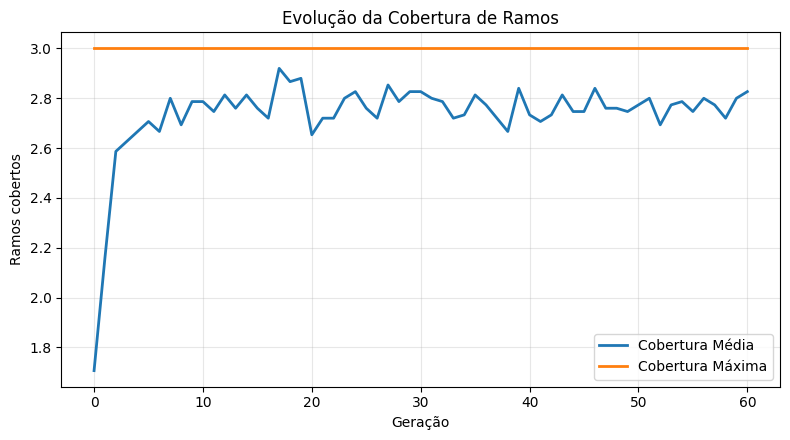

In [7]:
# @title Visualização da convergência
import matplotlib.pyplot as plt

gens = log.select('gen') if hasattr(log, 'select') else [rec['gen'] for rec in log]
avg_ = log.select('avg') if hasattr(log, 'select') else [rec['avg'] for rec in log]
max_ = log.select('max') if hasattr(log, 'select') else [rec['max'] for rec in log]

plt.figure(figsize=(8, 4.5))
plt.plot(gens, avg_, label='Cobertura Média', lw=2)
plt.plot(gens, max_, label='Cobertura Máxima', lw=2)
plt.xlabel('Geração')
plt.ylabel('Ramos cobertos')
plt.title('Evolução da Cobertura de Ramos')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
# [GRÁFICO: linhas para média e máximo por geração]

### Conclusões
- A instrumentação com `sys.settrace` e marcadores permite medir cobertura de forma não invasiva.
- A fitness baseada na contagem de ramos guia o AG a descobrir casos raros.
- A suíte construída cobre ramos essenciais com poucos casos, automatizando a geração de testes.